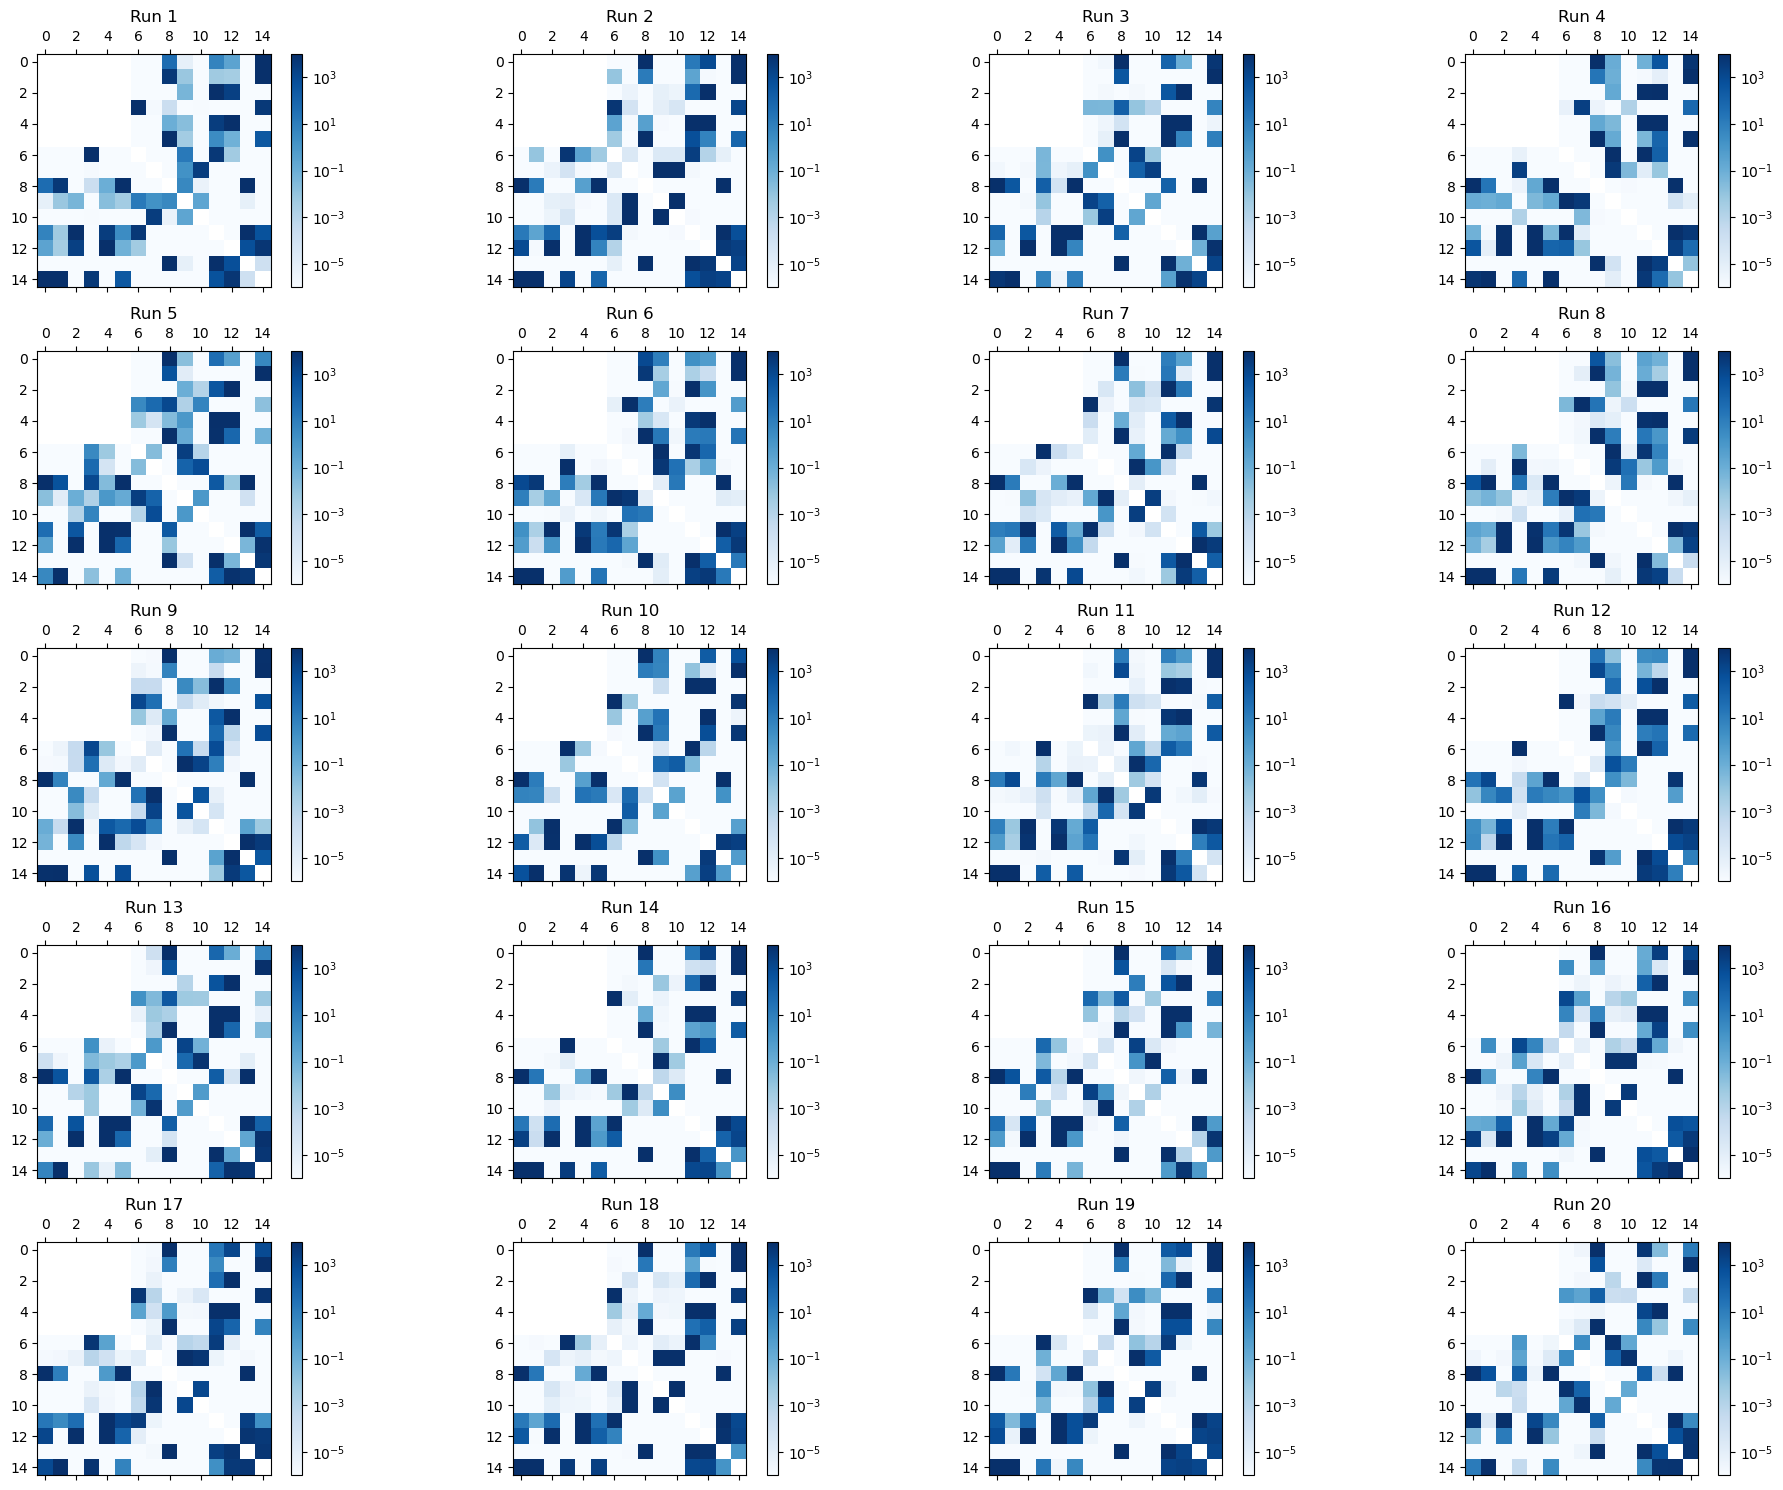

In [39]:
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import itertools



# Create a 5x4 figure to display all panels
fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()

list_best_perm = []

for i in range(1, 21):
        k_file = f'results_GD_noise0.5/GD_run{i}_noise0.5/K_matrix_D2.json'

        with open(k_file, 'r') as file:
                k_data = json.load(file)
                K = np.array(k_data['K'])
                K_clipped= np.clip(K, 1e-6, None)
        
        if(i==1):
                Kref=K
                Kref_clipped = np.clip(Kref, 1e-6, None)
                best_permutation=np.arange(0, K.shape[0])
                list_best_perm.append(best_permutation)
        v = [0, 1, 2, 3, 4, 5]
        if(i>1):
                min_distance = None
                for permutation in list(itertools.permutations(v)):
                        permutation_vector = np.array(permutation)
                        list_perm = np.concatenate(([0, 1, 2, 3, 4, 5], permutation_vector + 6, [12, 13, 14]))
                        #distance = np.sum((K1_clipped - K2_clipped[list_perm,:][:,list_perm])**2)
                        #distance = np.sum((K1-K2[list_perm,:][:,list_perm])**2)
                        distance = np.sum(np.log(Kref_clipped/K_clipped[list_perm,:][:,list_perm])**2)
                        if min_distance is None or distance < min_distance:
                                min_distance = distance
                                best_permutation = list_perm
                list_best_perm.append(best_permutation)

        # Plot each matrix in its respective subplot
        cax1 = axes[i - 1].matshow(K[best_permutation,:][:,best_permutation], cmap='Blues', norm=LogNorm())
        axes[i - 1].set_title(f'Run {i}')
        fig.colorbar(cax1, ax=axes[i - 1], fraction=0.046, pad=0.04)

# Adjust layout and display the figure
plt.tight_layout()
plt.show()


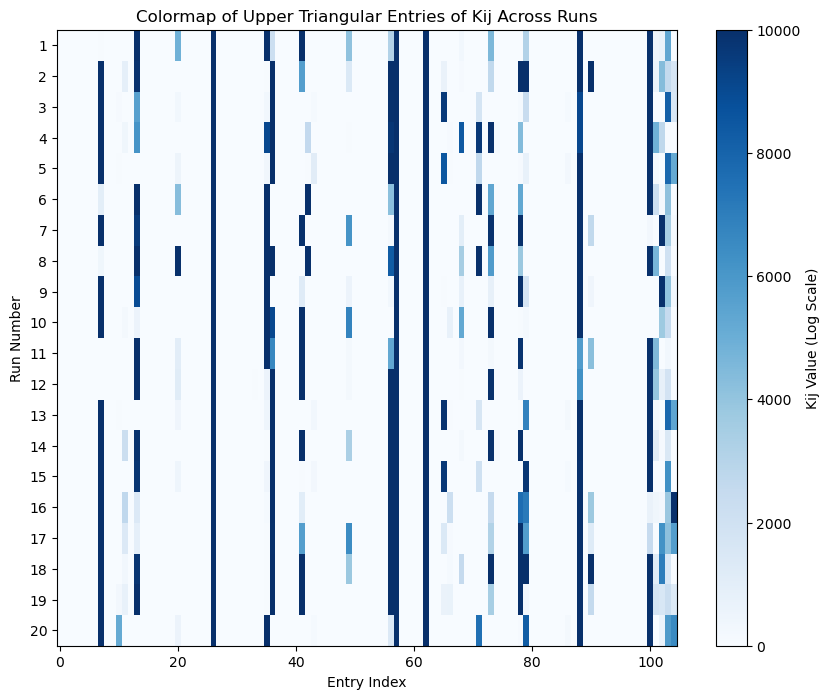

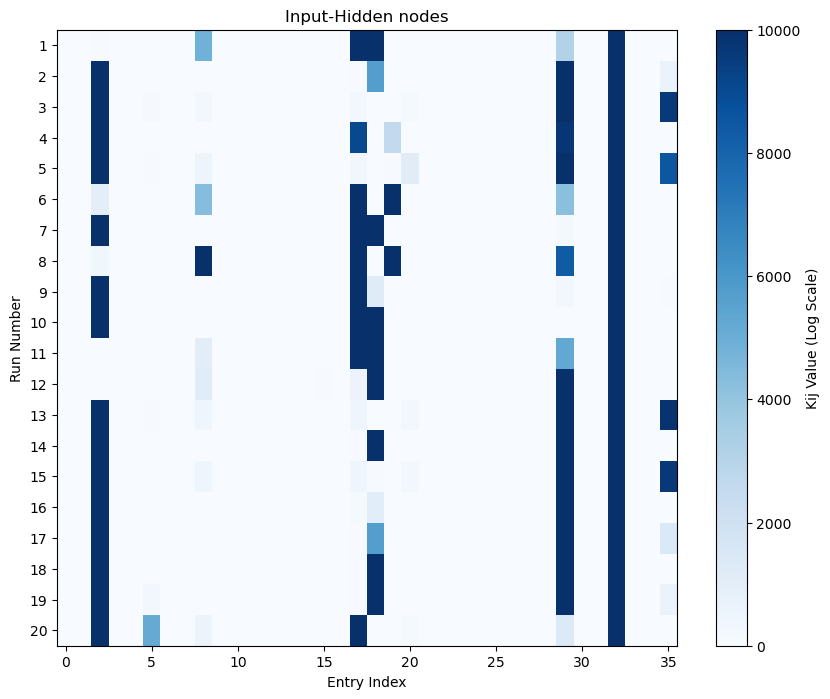

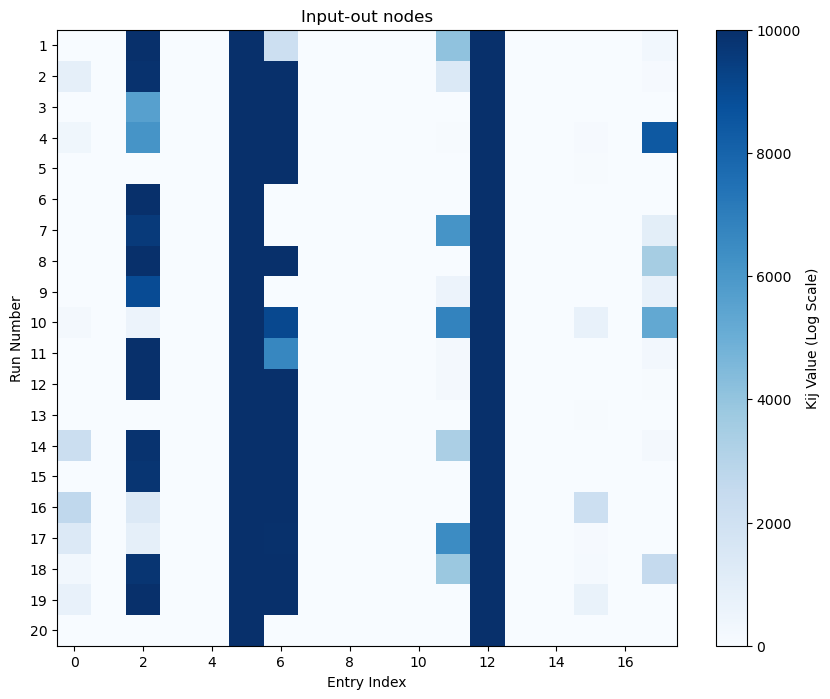

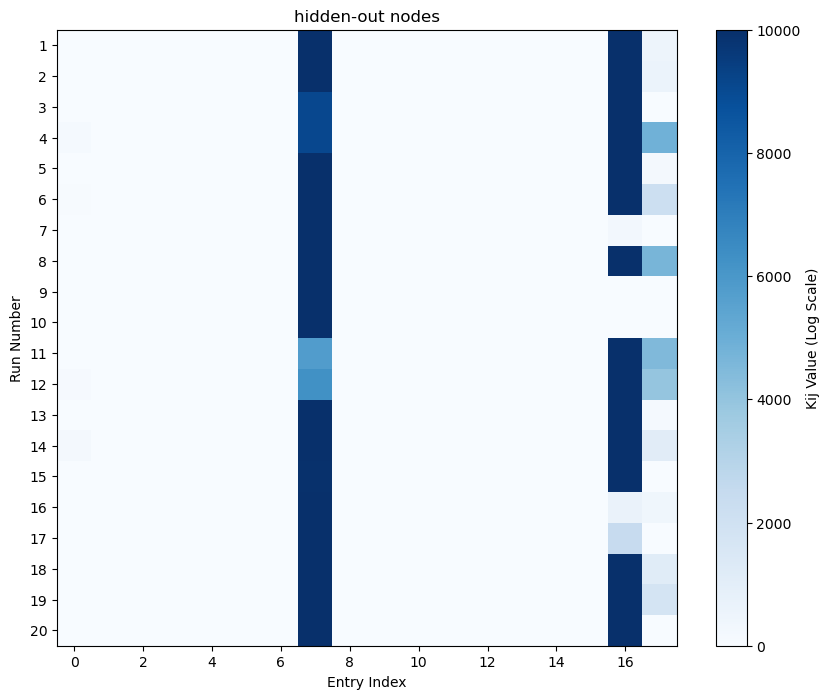

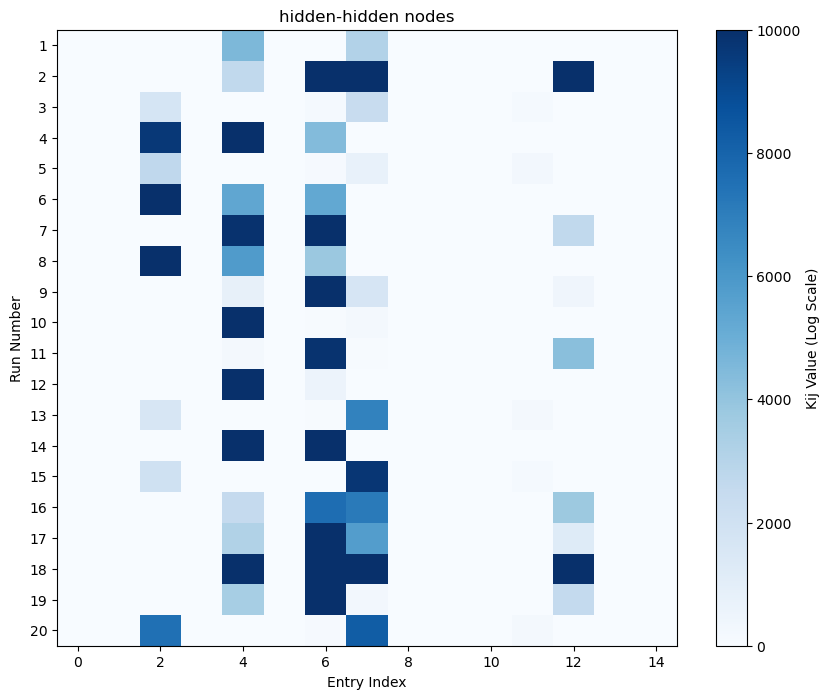

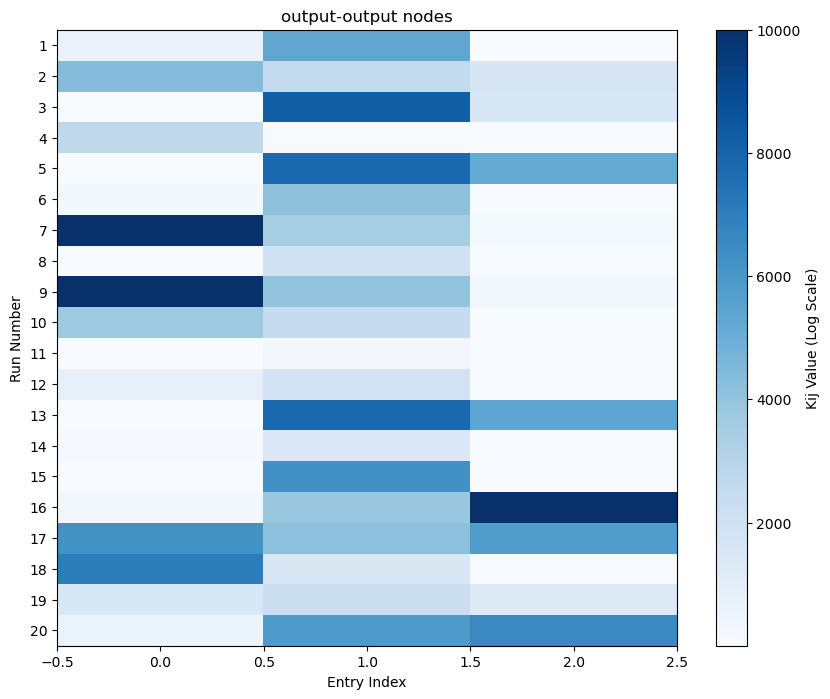

In [40]:
import numpy as np
import json
import matplotlib.pyplot as plt

# Initialize a list to store the upper triangular entries of K for each run
upper_triangular_entries = []
upper_triangular_ih_entries = []
upper_triangular_io_entries = []
upper_triangular_ho_entries = []
upper_triangular_hh_entries = []
upper_triangular_oo_entries = []


for i in range(1, 21):
    k_file = f'results_GD_noise0.5/GD_run{i}_noise0.5/K_matrix_D2.json'

    with open(k_file, 'r') as file:
        k_data = json.load(file)
        KK = np.array(k_data['K'])
        #K_clipped = np.clip(K, 1e-6, None)  # Clip values to avoid division by zero

    K = KK[list_best_perm[i-1],:][:,list_best_perm[i-1]]
    # Extract the upper triangular part of the matrix (excluding the diagonal)
    upper_triangular = K[np.triu_indices_from(K_clipped, k=1)]
    upper_triangular_entries.append(upper_triangular)

    upper_triangular_ih = K[np.ix_(np.arange(6), np.arange(6, 12))].flatten()
    upper_triangular_ih_entries.append(upper_triangular_ih)
    upper_triangular_io = K[np.ix_(np.arange(6), np.arange(12, 15))].flatten()
    upper_triangular_io_entries.append(upper_triangular_io)
    upper_triangular_ho = K[np.ix_(np.arange(6,12), np.arange(12, 15))].flatten()
    upper_triangular_ho_entries.append(upper_triangular_ho)
    upper_triangular_hh = K[np.ix_(np.arange(6, 12), np.arange(6, 12))][np.triu_indices(6, k=1)]
    upper_triangular_hh_entries.append(upper_triangular_hh)
    upper_triangular_oo = K[np.ix_(np.arange(12, 15), np.arange(12, 15))][np.triu_indices(3, k=1)]
    upper_triangular_oo_entries.append(upper_triangular_oo)

# Convert the list of upper triangular entries into a 2D array
# Each row corresponds to a run, and each column corresponds to an entry in the upper triangular part
upper_triangular_array = np.array(upper_triangular_entries)

upper_triangular_ih_array = np.array(upper_triangular_ih_entries)
upper_triangular_io_array = np.array(upper_triangular_io_entries)
upper_triangular_ho_array = np.array(upper_triangular_ho_entries)
upper_triangular_hh_array = np.array(upper_triangular_hh_entries)
upper_triangular_oo_array = np.array(upper_triangular_oo_entries)


# Create the colormap
plt.figure(figsize=(10, 8))
plt.imshow(upper_triangular_array, aspect='auto', cmap='Blues') #, interpolation='nearest')
plt.colorbar(label='Kij Value (Log Scale)')
plt.title('Colormap of Upper Triangular Entries of Kij Across Runs')
plt.xlabel('Entry Index')
plt.ylabel('Run Number')
plt.yticks(ticks=np.arange(20), labels=np.arange(1, 21))  # Label y-axis with run numbers
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(upper_triangular_ih_array, aspect='auto', cmap='Blues') #, interpolation='nearest')
plt.colorbar(label='Kij Value (Log Scale)')
plt.title('Input-Hidden nodes')
plt.xlabel('Entry Index')
plt.ylabel('Run Number')
plt.yticks(ticks=np.arange(20), labels=np.arange(1, 21))  # Label y-axis with run numbers
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(upper_triangular_io_array, aspect='auto', cmap='Blues') #, interpolation='nearest')
plt.colorbar(label='Kij Value (Log Scale)')
plt.title('Input-out nodes')
plt.xlabel('Entry Index')
plt.ylabel('Run Number')
plt.yticks(ticks=np.arange(20), labels=np.arange(1, 21))  # Label y-axis with run numbers
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(upper_triangular_ho_array, aspect='auto', cmap='Blues') #, interpolation='nearest')
plt.colorbar(label='Kij Value (Log Scale)')
plt.title('hidden-out nodes')
plt.xlabel('Entry Index')
plt.ylabel('Run Number')
plt.yticks(ticks=np.arange(20), labels=np.arange(1, 21))  # Label y-axis with run numbers
plt.show()


plt.figure(figsize=(10, 8))
plt.imshow(upper_triangular_hh_array, aspect='auto', cmap='Blues') #, interpolation='nearest')
plt.colorbar(label='Kij Value (Log Scale)')
plt.title('hidden-hidden nodes')
plt.xlabel('Entry Index')
plt.ylabel('Run Number')
plt.yticks(ticks=np.arange(20), labels=np.arange(1, 21))  # Label y-axis with run numbers
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(upper_triangular_oo_array, aspect='auto', cmap='Blues') #, interpolation='nearest')
plt.colorbar(label='Kij Value (Log Scale)')
plt.title('output-output nodes')
plt.xlabel('Entry Index')
plt.ylabel('Run Number')
plt.yticks(ticks=np.arange(20), labels=np.arange(1, 21))  # Label y-axis with run numbers
plt.show()


In [25]:
print(upper_triangular_ho)

[[9.99658951e-07 2.92176057e-06 9.99348130e-07]
 [9.97921297e-07 9.99014687e+03 3.56387866e+00]
 [9.99224355e-07 9.99112602e-07 9.99247366e-07]
 [9.98984056e-07 9.98777704e-07 9.98661057e-07]
 [9.99431055e-07 9.99481988e-07 9.98730868e-07]
 [1.79967467e-04 1.00000000e+04 9.97084695e-07]]
